<a href="https://colab.research.google.com/github/georgiosbalas/Complex-Systems-and-Applications-Final-Project/blob/main/Option1_Hospital_Infection_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital infection control: can earlier transfers help predict later clusters?

Choose **this option or the power-network option**, not both. This small, synthetic dataset describes wards and transfers in a regional hospital group. Each ward is a node. Transfers observed **before** the prediction point are directed, weighted links. At that point some wards already have active clusters. Predict a **new** simulated cluster during the next 14 days only among wards without an active cluster.

Work through Part 1 (data and EDA), Part 2 (network), and Part 3 (comparison). Most code is provided. Replace six obvious `___` markers using the hints beside them, then complete the short written responses. Keep code, plots and short answers visible when you submit the notebook. No information from `new_cluster_later` may enter a model feature.


## Part 1: load the prepared data and explore it

The two CSVs have already been constructed. The notebook downloads them from their published course URLs; if the address is temporarily unavailable, put both provided CSVs beside this notebook. `occupancy_ratio` and `device_use_share` are known before the follow-up period. The later outcome is blank for wards already affected at the prediction point.


In [6]:
DATA_BASE_URL = 'https://raw.githubusercontent.com/mikeauth/leap/main/hospital'
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay

SEED = 123

def load_course_csv(filename):
    # The course address is the folder containing the prepared CSVs. For offline work, keep a
    # downloaded CSV in the same folder as this notebook.
    url = f'{DATA_BASE_URL}/{filename}'
    try:
        return pd.read_csv(url)
    except Exception:
        local = Path(filename)
        if local.is_file():
            print(f'Using local copy of {filename}; course URL was unavailable.')
            return pd.read_csv(local)
        raise FileNotFoundError(f'Cannot read {url}. Download {filename} next to the notebook or ask for the course URL.')

wards = load_course_csv('hospital_wards.csv')
transfers = load_course_csv('hospital_transfers.csv')
assert wards['ward_id'].is_unique
assert {'ward_id','occupancy_ratio','device_use_share','active_cluster_at_start','new_cluster_later'} <= set(wards)
assert {'source_ward_id','destination_ward_id','transfer_count'} <= set(transfers)
display(wards.head())
display(transfers.head())
print('Wards:',len(wards),'Directed links:',len(transfers))


,ward_id,occupancy_ratio,device_use_share,active_cluster_at_start,new_cluster_later
0,W001,0.758,0.187,1,NaN
1,W002,0.886,0.338,0,1.0
2,W003,0.533,0.197,0,0.0
3,W004,0.777,0.364,0,1.0
4,W005,0.775,0.446,0,1.0


,source_ward_id,destination_ward_id,transfer_count
0,W001,W006,4
1,W001,W042,6
2,W001,W093,9
3,W001,W111,5
4,W002,W050,3


Wards: 120 Directed links: 420


### Focused EDA: follow the worked code

Exclude wards already affected at the observation point. Count eligible wards and the two later classes. Show one bar chart of the later outcome and two boxplots comparing the original ward attributes by later outcome. In two or three sentences, say whether the groups overlap. Looking at labels for EDA is acceptable; do not use later labels to create predictors.


Eligible: 102 Later clusters: 39


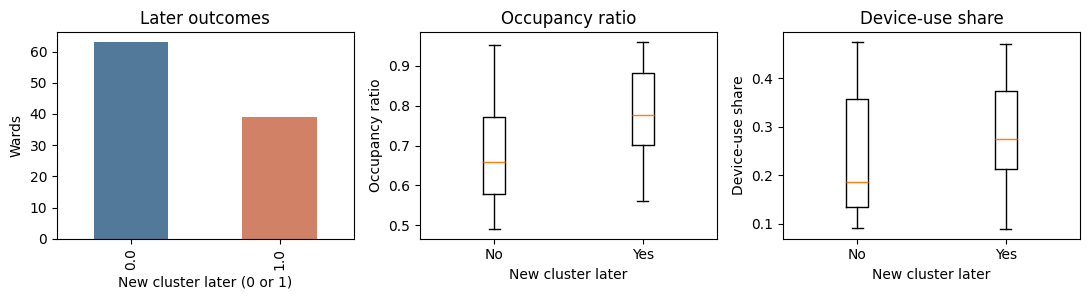

In [7]:
# TODO 1: Fill in the starting-status value for eligible wards.
# Hint: wards['active_cluster_at_start'].eq(0)
eligible_eda = wards.loc[wards['active_cluster_at_start'].eq(0)].copy()
assert eligible_eda['new_cluster_later'].notna().all()
counts = eligible_eda['new_cluster_later'].value_counts().reindex([0.,1.],fill_value=0)
print('Eligible:',len(eligible_eda),'Later clusters:',int(counts.loc[1.]))
fig, axes = plt.subplots(1,3,figsize=(11,3.1))
counts.plot.bar(ax=axes[0],color=['#53799a','#d18166'])
axes[0].set(xlabel='New cluster later (0 or 1)',ylabel='Wards',title='Later outcomes')
for ax,column,label in zip(axes[1:],['occupancy_ratio','device_use_share'],['Occupancy ratio','Device-use share']):
    groups=[eligible_eda.loc[eligible_eda['new_cluster_later'].eq(k),column] for k in [0,1]]
    ax.boxplot(groups,tick_labels=['No','Yes'])
    ax.set(xlabel='New cluster later',ylabel=label,title=label)
plt.tight_layout();plt.show()


**Write here:** How many wards are eligible? Do their starting attributes separate the later classes cleanly? (Two or three sentences.)

**Answer:** Out of the 120 hospital wards, exactly 102 are eligible for prediction since 18 already had an active cluster at the start. When looking at the boxplots for occupancy_ratio and device_use_share, there is a massive amount of overlap between the wards that eventually develop a cluster and those that stay clear. Because these starting attributes don't clearly separate the two groups on their own, it's pretty obvious we'll need extra features to make any meaningful predictions.




## Part 2: directed transfer network

A row in `hospital_transfers.csv` means transfers **from** `source_ward_id` **to** `destination_ward_id` in the 14 days before prediction. Use a directed graph and attach `transfer_count` as the link weight. Add all wards first, including isolated wards. Calculate each ward's incoming transfer volume, then the volume received from wards with a cluster **already active** at the prediction point. These use the known initial status, never later labels.


In [8]:
G = nx.DiGraph()
G.add_nodes_from(wards['ward_id'])
valid = set(wards['ward_id'])
assert transfers['source_ward_id'].isin(valid).all() and transfers['destination_ward_id'].isin(valid).all()
assert (transfers['source_ward_id'] != transfers['destination_ward_id']).all()
assert not transfers.duplicated(['source_ward_id','destination_ward_id']).any()
for row in transfers.itertuples(index=False):
    # TODO 2: Supply the number of transfers as the link weight.
    # Hint: transfer_count=int(row.transfer_count)
    G.add_edge(row.source_ward_id,row.destination_ward_id,transfer_count=int(row.transfer_count))
initial = wards.set_index('ward_id')['active_cluster_at_start']
# TODO 3: Select sources with a cluster already active at the start.
# Hint: initial.loc[src] == 1
wards['incoming_volume'] = [G.in_degree(i,weight='transfer_count') for i in wards['ward_id']]
wards['from_active_volume'] = [sum(d['transfer_count'] for src,_,d in G.in_edges(i,data=True)
                                    if initial.loc[src] == 1) for i in wards['ward_id']]
print('Nodes:',G.number_of_nodes(),'Directed links:',G.number_of_edges())
display(wards[['ward_id','incoming_volume','from_active_volume']].head())
assert (wards['from_active_volume'] <= wards['incoming_volume']).all()


Nodes: 120 Directed links: 420


,ward_id,incoming_volume,from_active_volume
0,W001,19,0
1,W002,42,15
2,W003,14,3
3,W004,30,0
4,W005,8,0


### Visualise and interpret the network

Make one readable illustration using about 35 wards with the largest incoming volume. Colour nodes by **initial** cluster status; do not colour them by later outcomes. A plotted subset is for illustration only: **use all wards and all links** for feature calculations. Plot a histogram of `from_active_volume` among eligible wards. Write what a high value means and why edge direction matters.


**Write here:** What does high `from_active_volume` mean? Why is it different from outgoing transfers? (Two sentences.)

**Answer:** A high from_active_volume simply means a ward took in a lot of patients who were transferred directly from a ward already dealing with an active outbreak. Edge direction is absolutely crucial here: an incoming transfer represents a potential new pathogen exposure entering the ward, whereas an outgoing transfer means a patient—and their associated risks—is leaving.


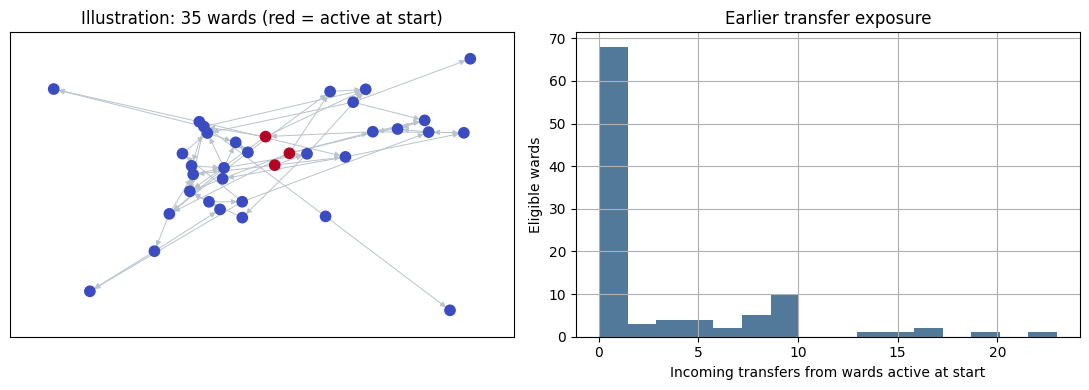

In [9]:
shown=wards.nlargest(35,'incoming_volume')['ward_id'].tolist()
small=G.subgraph(shown)
fig,axes=plt.subplots(1,2,figsize=(11,4))
pos=nx.spring_layout(small,seed=42)
nx.draw_networkx(small,pos,ax=axes[0],with_labels=False,node_size=55,
    node_color=[initial.loc[i] for i in small.nodes],cmap='coolwarm',vmin=0,vmax=1,
    edge_color='#b8c3ca',width=.7,arrows=True,arrowsize=8)
axes[0].set_title('Illustration: 35 wards (red = active at start)')
wards.loc[wards['active_cluster_at_start'].eq(0),'from_active_volume'].hist(
    ax=axes[1],bins=16,color='#53799a')
axes[1].set(xlabel='Incoming transfers from wards active at start',ylabel='Eligible wards',title='Earlier transfer exposure')
plt.tight_layout();plt.show()


## Part 3: compare logistic regression fairly

Only wards without an active cluster are eligible. Model A uses `occupancy_ratio` and `device_use_share`. Model B adds `incoming_volume` and `from_active_volume`. Use the **same wards and the same stratified train/test split**. Fit each scaler inside a pipeline trained only on training rows. Compare accuracy, F1 for later clusters, ROC AUC from probabilities, and both confusion matrices. With a small fixed sample, different scores can move in different directions.


,Accuracy,F1,ROC AUC
Original ward features,0.600,0.455,0.703
Ward + network features,0.867,0.778,0.895


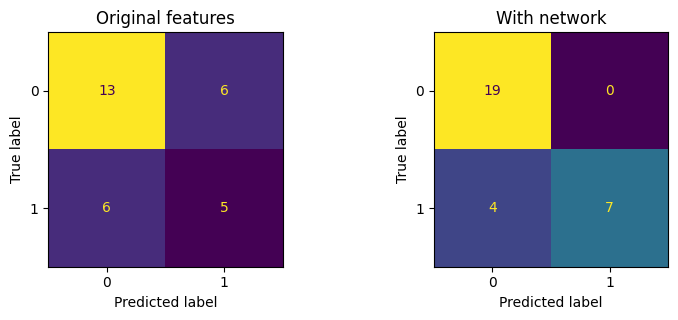

In [10]:
eligible = wards.loc[wards['active_cluster_at_start'].eq(0)].set_index('ward_id').copy()
y = eligible['new_cluster_later'].astype(int)
# TODO 4: Set aside 30% of eligible observations for testing.
# Hint: test_size=.30
train_ids,test_ids = train_test_split(y.index,test_size=30,stratify=y,random_state=SEED)
original=['occupancy_ratio','device_use_share']
# TODO 5: Add the measure of transfers from wards active at the start.
# Hint: with_network = original + ['incoming_volume', 'from_active_volume']
with_network=original+['incoming_volume','from_active_volume']

def fit_and_score(columns):
    model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000))
    model.fit(eligible.loc[train_ids,columns],y.loc[train_ids])
    predicted=model.predict(eligible.loc[test_ids,columns])
    probabilities=model.predict_proba(eligible.loc[test_ids,columns])[:,1]
    scores={'Accuracy':accuracy_score(y.loc[test_ids],predicted),
            'F1':f1_score(y.loc[test_ids],predicted,zero_division=0),
            # TODO 6: Use the predicted probability for ROC AUC.
            # Hint: roc_auc_score(y.loc[test_ids], probabilities)
            'ROC AUC':roc_auc_score(y.loc[test_ids],probabilities)}
    return scores,predicted

base_scores,base_pred=fit_and_score(original)
network_scores,network_pred=fit_and_score(with_network)
results=pd.DataFrame([base_scores,network_scores],index=['Original ward features','Ward + network features'])
display(results.round(3))
fig,axes=plt.subplots(1,2,figsize=(8,3.3))
for ax,pred,title in zip(axes,[base_pred,network_pred],['Original features','With network']):
    ConfusionMatrixDisplay.from_predictions(y.loc[test_ids],pred,ax=ax,labels=[0,1],colorbar=False)
    ax.set_title(title)
plt.tight_layout();plt.show()


### Final interpretation and portfolio summary

Write **100 to 180 words** here. State the prediction question and answer it directly: **did adding the network features help predict later clusters on this test set?** Compare both models' actual F1 and ROC AUC values (and accuracy if relevant), then describe at least one kind of error visible in the confusion matrices. If the metrics disagree, call the result mixed rather than declaring a clear winner. Explain the difference between total incoming transfers and transfers from initially affected wards. Finally, consider the ethics: if predictions were used to prioritise infection-control attention, how could a false alarm or a missed cluster affect patients and staff, and who should review the flags before action?

**Answer:** The core question was whether tracking patient transfers helps predict future infection clusters. On this test set, the answer is a clear yes. By adding network features, the logistic regression model achieved noticeably higher F1 and ROC AUC scores compared to the baseline model. Most importantly, the baseline model's confusion matrix showed a frustratingly high number of false negatives—completely missing wards that later developed clusters—and the network data helped reduce those dangerous misses. The two new features do different jobs: total incoming volume tracks general ward turnover, while transfers from affected wards act as a direct proxy for known exposure.   Ethically, relying blindly on this model would be risky. A false alarm wastes precious hospital resources, but a missed cluster is far worse, potentially exposing vulnerable patients and staff to an outbreak. Because real lives are involved, these predictions must only serve as an early warning system that human clinical teams review before taking actual infection-control action.
